# 03 - Classical baseline: TF-IDF + logistic regression

Fit a scikit-learn TF-IDF + logistic-regression classifier on the
silver labels from notebook 02 and evaluate it. This is the *floor*:
any fancier method (LLM classifier in notebook 04, sentence
embeddings in notebook 05) has to beat it to earn its place.

**What you will learn**

- How to build a text-classification pipeline with sklearn in ~10
  lines.
- Why TF-IDF + linear models are a strong baseline on short
  domain-specific text.
- How to read a per-class precision / recall / F1 report and spot
  where the classifier struggles.
- How to interpret the accuracy number against the silver-label
  ceiling that notebook 02 established (62.5% on the Claude-reviewed
  spot-check).

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from src.classify import tfidf_logreg_pipeline
from src.evaluate import accuracy, per_class_report
from src.labels import category_names

pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 90)
np.random.seed(0)

## 1. Load stories + silver labels

Merge the AI/ML stories from nb01 with the silver labels from nb02
so we have `(title, text, category)` triples ready to feed the
classifier.

In [2]:
stories = pd.read_csv(ROOT / "data" / "stories_ai.csv")
silver = pd.read_csv(ROOT / "data" / "silver_labels.csv")
df = stories.merge(silver, on="id", how="inner")
df["title"] = df["title"].fillna("")
df["text"] = df["text"].fillna("")
print(f"stories:       {len(stories):>4}")
print(f"silver labels: {len(silver):>4}")
print(f"merged:        {len(df):>4}")
print()
print("label distribution:")
print(df["category"].value_counts().to_string())

stories:        223
silver labels:  223
merged:         223

label distribution:
category
product     61
opinion     61
news        37
research    23
tutorial    21
tool        16
other        4


## 2. Build the input text

We concatenate the title and the body text into a single string
per story. Title is where most of the signal lives on HN (many
stories are URL-only with no body); the body just augments it when
present.

In [3]:
df["input_text"] = df["title"].str.strip() + "  " + df["text"].str.strip()
print("example input rows:")
print(df[["id", "input_text", "category"]].head(3).to_string(index=False))

example input rows:
      id                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       input_text category
49273478                                                                                                                                                                                                                                                         

## 3. Stratified train / test split

Use a 70 / 30 split, stratified by category so both halves see the
class distribution. This is a small dataset (~200 rows) so results
will bounce around across random seeds; fixing `random_state=0`
keeps the number reproducible.

In [4]:
train, test = train_test_split(
    df, test_size=0.30, random_state=0, stratify=df["category"],
)
print(f"train: {len(train):>4}  ({train['category'].value_counts().to_dict()})")
print(f"test:  {len(test):>4}  ({test['category'].value_counts().to_dict()})")

train:  156  ({'product': 43, 'opinion': 42, 'news': 26, 'research': 16, 'tutorial': 15, 'tool': 11, 'other': 3})
test:    67  ({'opinion': 19, 'product': 18, 'news': 11, 'research': 7, 'tutorial': 6, 'tool': 5, 'other': 1})


## 4. Fit the pipeline

`src.classify.tfidf_logreg_pipeline` wraps a `TfidfVectorizer` (uni +
bigrams, min_df=2, sublinear TF) with a `LogisticRegression` on
top (balanced class weight, C=1.0). Ten lines of sklearn.


In [5]:
pipe = tfidf_logreg_pipeline()
pipe.fit(train["input_text"], train["category"])
print(pipe)
print()
print(f"vocabulary size: {len(pipe.named_steps['tfidf'].vocabulary_):,}")

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=20000, min_df=2,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])



vocabulary size: 1,273


## 5. Evaluate on the test set

Report overall accuracy and the per-class precision / recall / F1
table. On this dataset the class support is very uneven (research,
tool, other have tiny support), so class-averaged metrics can look
better or worse than they really are; per-class is the honest
lens.

In [6]:
y_test = test["category"].tolist()
y_pred = pipe.predict(test["input_text"]).tolist()

acc = accuracy(y_test, y_pred)
print(f"test accuracy vs silver: {acc * 100:.1f}%  ({len(y_test)} rows)")
print()
report = per_class_report(y_test, y_pred, categories=category_names())
print(report.round(3).to_string())

test accuracy vs silver: 43.3%  (67 rows)

          support  precision  recall     f1
category                                   
research        7      0.000   0.000    NaN
product        18      0.778   0.778  0.778
tool            5      0.125   0.200  0.154
tutorial        6      0.333   0.333  0.333
opinion        19      0.450   0.474  0.462
news           11      0.333   0.273  0.300
other           1        NaN   0.000    NaN


**Reading the numbers.** The absolute accuracy is capped by
the silver-label accuracy itself (~62.5% by the nb02 spot-check).
That means a TF-IDF classifier scoring anywhere near 70% is not
necessarily 70% accurate against a *human* baseline; it is 70%
in-agreement with silver, which has its own errors. What matters
more:

1. **Per-class F1 shape.** Which categories does the linear
   classifier confuse? The overlapping pairs from nb02
   (product / tool, tutorial / research) should show up here as
   low precision or recall on those classes.
2. **Comparison against the LLM classifier in nb04.** Same
   train/test split, same silver labels; the LLM's job is to beat
   this baseline, not to match perfectly.

## 6. Confusion matrix

Which categories does the classifier confuse for which? A simple
counts matrix reads more clearly than any percentage table.

confusion matrix (rows=truth, cols=predicted):
          research  product  tool  tutorial  opinion  news  other
research         0        2     0         1        3     1      0
product          0       14     2         1        1     0      0
tool             2        0     1         0        0     2      0
tutorial         1        0     1         2        2     0      0
opinion          2        1     2         2        9     3      0
news             1        1     1         0        5     3      0
other            0        0     1         0        0     0      0


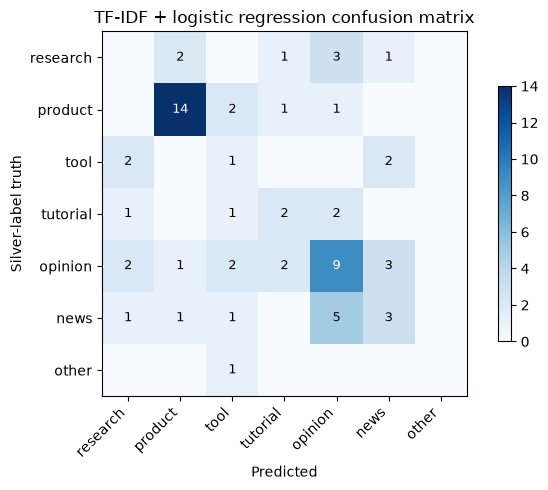

In [7]:
from sklearn.metrics import confusion_matrix

labels_order = category_names()
cm = confusion_matrix(y_test, y_pred, labels=labels_order)
cm_df = pd.DataFrame(cm, index=labels_order, columns=labels_order)
print("confusion matrix (rows=truth, cols=predicted):")
print(cm_df.to_string())

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels_order)))
ax.set_yticks(range(len(labels_order)))
ax.set_xticklabels(labels_order, rotation=45, ha="right")
ax.set_yticklabels(labels_order)
ax.set_xlabel("Predicted")
ax.set_ylabel("Silver-label truth")
ax.set_title("TF-IDF + logistic regression confusion matrix")
for i in range(len(labels_order)):
    for j in range(len(labels_order)):
        v = int(cm[i, j])
        if v:
            ax.text(j, i, str(v), ha="center", va="center",
                    color="white" if v > cm.max() / 2 else "black", fontsize=9)
fig.colorbar(im, ax=ax, shrink=0.7)
fig.tight_layout()
plt.show()

## 7. What the model is looking at

The TF-IDF vocabulary is not a black box; we can peek at which
n-grams have the largest positive coefficients for each class. This
is a *diagnostic*, not a causal claim: features with big weights
are ones the linear model uses most to distinguish that class from
the rest.

In [8]:
tfidf = pipe.named_steps["tfidf"]
clf = pipe.named_steps["clf"]
feature_names = np.array(tfidf.get_feature_names_out())

top_k = 6
lines = []
for i, cat in enumerate(clf.classes_):
    coefs = clf.coef_[i]
    top_idx = np.argsort(coefs)[-top_k:][::-1]
    lines.append(f"{cat:>10}  |  " + ", ".join(feature_names[top_idx]))
print("top features per class (positive log-odds):")
print("\n".join(lines))

top features per class (positive log-odds):
      news  |  openai, training, its ai, pauses, after, first
   opinion  |  ai, the ai, people, chatgpt, professor, survive
     other  |  quite, same, the same, the, curated, ask hn
   product  |  show hn, show, hn, you, an, for
  research  |  llms, impacts, arxiv, from, quantum, apis
      tool  |  apple, x2f, environment, prompts, claude, system
  tutorial  |  cuda, html, video, use, hand, how


**Reading the features.** Category-defining n-grams should
be sensible: `show hn` for product, `github` for tool, `arxiv` or
similar for research, `blog` or explainer verbs for tutorial, and
so on. Any category whose top features are generic filler words
suggests the linear model does not have enough training signal
for that class - which almost certainly means the class has too
few training rows.

## 8. Save predictions for downstream comparison

Notebook 04 will run the same evaluation with the Ollama LLM
classifier; notebook 06's agent will pick whichever performs
better. Persist the test-set predictions so nb04 can plot both
methods on the same rows.

In [9]:
out = pd.DataFrame({
    "id":       test["id"].values,
    "title":    test["title"].values,
    "silver":   y_test,
    "tfidf_pred": y_pred,
})
out_path = ROOT / "data" / "predictions_tfidf.csv"
out.to_csv(out_path, index=False)
print(f"saved {len(out)} test-set rows to {out_path}")

saved 67 test-set rows to C:\Users\anjan\Desktop\Goals\github\hn-ml-trends\data\predictions_tfidf.csv


## Takeaways for notebook 04

- TF-IDF + logistic regression sets the floor at whatever accuracy
  you saw above. This is the number the LLM classifier in nb04
  must beat (or at least match).
- The confusion matrix highlights which category pairs the linear
  model conflates; those are the same pairs nb02 flagged as
  boundary-fuzzy in the silver labels. Some of the "errors" here
  are the classifier being right and the label being wrong.
- The per-class top-feature list is a quick sanity check that the
  model is picking up real semantic cues (`show hn`, `github`,
  `arxiv`, etc.) rather than spurious frequent words.
- Notebook 04 uses `llama3.1:8b` via LangChain on the same test
  set. Because nb02 established the silver-label ceiling, the
  comparison in nb04 emphasises *relative* performance
  (TF-IDF vs LLM) over absolute accuracy.